------------------------------------------------------------
# My Blue Bin Recycling Assistant
--------------------------------------------------------------
* Born out of the frustration of not knowing what is recyclable and not in the blue comingle recycling bin below my HDB block :")
----------------------
## **Objective**  
----------------------

* Develop a computer vision application that accepts images from a webcam or local upload to classify the material of a waste item (e.g., plastic, paper, glass, metal) with a confidence score, and then determine its recyclability using a rule-based decision engine based on the predicted material and user-provided conditions (e.g., cleanliness, dryness, rigidity).

------------------------------------
## **Dataset Description**
------------------------------------
* It covers the following waste categories and items:
    - Plastic: water bottles, soda bottles, detergent bottles, shopping bags, trash bags, food containers, disposable cutlery, straws, cup lids
    - Paper and Cardboard: newspaper, office paper, magazines, cardboard boxes, cardboard packaging
    - Glass: beverage bottles, food jars, cosmetic containers
    - Metal: aluminum soda cans, aluminum food cans, steel food cans, aerosol cans
    - Organic Waste: food waste (fruit peels, vegetable scraps), eggshells, coffee grounds, tea bags
    - Textiles: clothing, shoes

## Install and import relevant packages or libraries 

In [ ]:
!pip install mlflow -q
!pip install gradio -q


In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import tensorflow as tf
import mlflow
import mlflow.keras
import subprocess
import gradio as gr
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import kagglehub
path = kagglehub.dataset_download("alistairking/recyclable-and-household-waste-classification")

In [ ]:
'''from google.colab import drive
drive.mount('/content/drive')

mlflow.set_tracking_uri("sqlite:////content/drive/MyDrive/mlflow.db")'''

In [ ]:
import mlflow

mlflow.set_tracking_uri("sqlite:////kaggle/working/mlflow.db")

## Exploratory Data Analysis

In [ ]:
#check what is the data type of the file downloaded
for f in os.listdir(path):
  print(f)

In [ ]:
# explore whats inside images folder
images_path=os.path.join(path,'images','images')#added second images after running for the first time
for category in os.listdir(images_path):
  print(category)

In [ ]:
#explore whats inside each category folder
for category in os.listdir(images_path):
  category_path=os.path.join(images_path,category)

In [ ]:
#convert to tabular format for easier analysis

data=[]

for category in os.listdir(images_path):
  category_path=os.path.join(images_path,category)

  for source in ["real_world","default"]:
    source_path=os.path.join(category_path,source)

    for file in os.listdir(source_path):
        if file.lower().endswith((".png",".jpeg",".jpg")):
          data.append({"file_path":os.path.join(source_path,file),
                    "category":category,
                    "source":source})

df=pd.DataFrame(data)





In [ ]:
df.head()

In [ ]:
df["source"].unique()

In [ ]:
#visualise how "real_world" images look like
real_world_images= df[df["source"]=="real_world"]
default_images=df[df["source"]=="default"]

for file in real_world_images["file_path"].head(5):
    img=Image.open(file)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [ ]:
#visualise how default images look like
for file in default_images["file_path"].head(5):
    img=Image.open(file)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

### Observations:
* Real world images contain shadows and different backgrounds. It also shows upcycled/resused versions of the orignal items.
* Default images mostly have white backgrounds and less variety(only shows the item in its original form)

According to the dataset description on Kaggle:
1. "default": Contains standard or studio-like images of the waste item.
2. "real_world": Contains images of the waste item in real-world scenarios or environments.


### Note:


1.   Refactor code for readability
2.   Remove white spaces in images?
3.   Whats the difference between default and real world images
4.   No class imbalance since equal number of photos for each category




In [ ]:
# summary count of images

df.groupby("category")["source"].value_counts()


In [ ]:
sizes=real_world_images["file_path"].apply(lambda x: Image.open(x).size)
print(sizes.value_counts())


### Observations:
* There is no class imabalance since there's an equal number of photos for each category
* Size and width (256 x 256)  are consistent for all images

In [ ]:
# brightness & contrast distribution by calculating mean intensity and standard deviation of an image pixel values respectively

# first convert to grayscale


brightness=[]
contrast=[]

for i in df["file_path"]:
  img=Image.open(i).convert("RGB")
  img_array=np.array(img)
  gray=cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
  brightness.append(gray.mean())
  contrast.append(gray.std())






In [ ]:

df["brightness"]=brightness
df["contrast"]=contrast

In [ ]:
df.groupby("category")[["brightness","contrast"]].mean()

In [ ]:
# see distributions
plt.figure(figsize=(24,8))
sns.boxplot(x="category", y="brightness", data=df)
plt.title("Brightness by Category")
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(24, 8))
sns.boxplot(x="category", y="contrast", data=df)
plt.title("Contrast by Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#check for corrupt files

corrupt_files=[]

for i in df["file_path"]:
  try:
    img=Image.open(i)
    img.verify()
  except Exception:
    corrupt_files.append(i)

print(f"total corrupt files:{len(corrupt_files)}")


### Observations:
* Interquartile Range for all categories for brightnessis  falls between 150 to 250. This shows that brightness is pretty consistent across all categories
* Cardboard, Plastic products (e.g plastic detergent bottles, plastic food containers,plastic straws,disposable plastic cutlery) and Glass products (e.g glass cosmetic containers,glass food jars) have the most outliers in the brighness categories which may affect downstream model performances for predicting for these categories.
* For Contrast, there is more variability in the iq ranges across the different categories indicating that contrast values are incosistent within each product/item type.
* Styrofoam products(styrofoam cups,styrofoam food containers) have the largest IQR range and longest whiskers indicating high inconsistency within this category
* As compared to brightness, contrast shows substantial inconsistency within product types 
* All images are valid since there are no corrupt files 
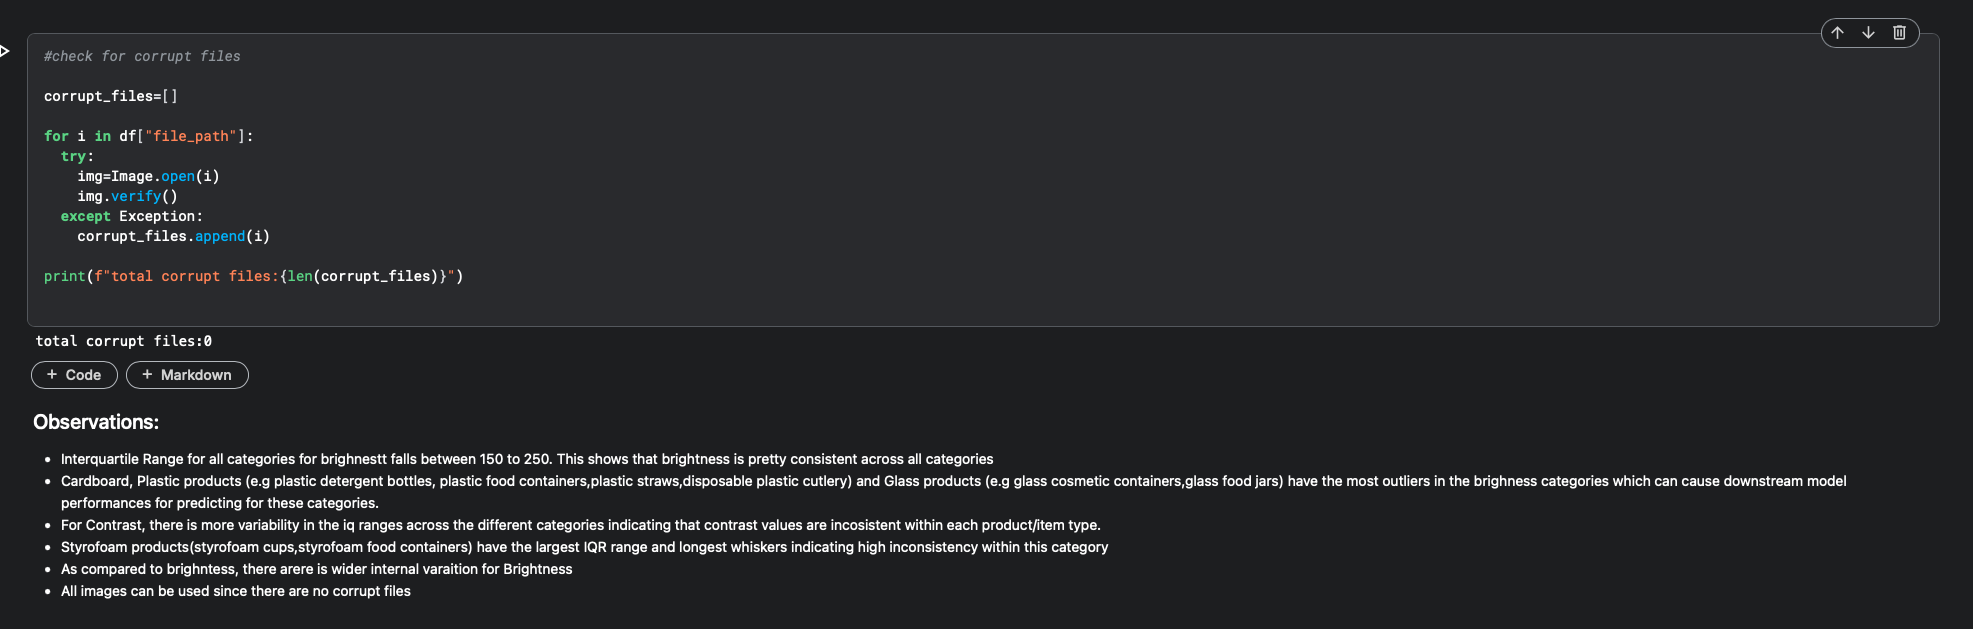

## Feature Engineering: 
* define class labels +recyclability mapping based on Singapore's blue recycling bin's criteria
    
  What can be recycled:
    * Paper
    * Plastic
    * Metal
    * Glass



In [ ]:
#unique category
df["category"].unique()

In [ ]:
#recylcability mapping + material type
def get_material(category: str)-> str:

    if "plastic" in category:
        return "plastic"

    elif "glass" in category:
        return "glass"

    elif any(k in category for k in ['aluminum','aerosol','steel']):
        return "metal"

    elif "cardboard" in category:
        return "paper"

    elif category in ["office_paper", "paper_cups", "newspaper", "magazines"]:
        return "paper"

    elif "styrofoam" in category:
        return "styrofoam"

    elif category in ["coffee_grounds", "tea_bags", "food_waste", "eggshells"]:
        return "organic"

    elif category in ["clothing","shoes"]:
        return "textile"

    else:
        return "unknown"

In [ ]:
df["material"]=df["category"].map(get_material)

In [ ]:
df.head()

In [ ]:
#material recyclability

material_defaults={
    "plastic": True,
    "paper": True,
    "glass": True,
    "metal": True,
    "styrofoam": False,
    "organic": False,
    "textile": False,
    "unknown": False,
}

'''exclude specific items that are not recyclable even though they are made from
recyclable materials'''

item_override={
    "plastic_straws": False,
    "plastic_shopping_bags": False,
    "plastic_cup_lids": False,
    "plastic_trash_bags": False,
    "disposable_plastic_cutlery": False,
    "paper_cups": False,
    "tea_bags": False,
}

def recyclability(category: str)-> bool:
  if category in item_override:
      return item_override.get(category)
  else:
      material_type=get_material(category)
      return material_defaults.get(material_type,False)






In [ ]:
df["recyclable"]=df["category"].map(recyclability)

In [ ]:
df.head()

## Split into train/test/validation

In [ ]:
# 70% train,15% validation,%15 test
train_ratio=0.70
val_ratio=0.15
test_ratio=0.15


train_df,temp_df=train_test_split(df,test_size=0.30,stratify=df["category"],random_state=42)

val_df,test_df=train_test_split(temp_df,test_size=0.5,stratify=temp_df["category"],random_state=42)


In [ ]:
#groups images into batches and send them to cnn during training


datagen=ImageDataGenerator()

train_gen=datagen.flow_from_dataframe(
    train_df,
    x_col="file_path",
    y_col="category",
    batch_size=32,
    target_size=(160,160),#adjust size from (256,256) to (160,160),cnn requires all images to be the same size
    class_mode="categorical" #multi-class classification

)

val_gen=datagen.flow_from_dataframe(
    val_df,
    x_col="file_path",
    y_col="category",
    batch_size=32,
    target_size=(160,160),
    class_mode="categorical")

test_gen=datagen.flow_from_dataframe(
    test_df,
    x_col="file_path",
    y_col="category",
    batch_size=32,
    target_size=(160,160),
    class_mode="categorical")




## Data Augmentation for CNN


In [ ]:
# random rotation
# random noise
# zoom
#random_brightness
#random contrast


data_aug_cnn = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),  
    layers.RandomZoom(0.1),      
    layers.RandomContrast(0.1),  
    layers.RandomBrightness(0.1),  
])






## Build CNN Model using tensor flow

In [ ]:
model=tf.keras.Sequential([
    data_aug_cnn,
    layers.Rescaling(1./255), #normalize image pixel values

    layers.Conv2D(32, (3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(units=30,activation="softmax")
])

## Compile the model

In [ ]:
# early stopping of epochs

early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint=tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
     monitor="val_accuracy",
     save_best_only=True)



In [ ]:

mlflow.set_experiment("recyclability_classfication")

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

with mlflow.start_run(run_name="CNN_baseline") as run_cnn:
  mlflow.log_param("model","CNN")
  mlflow.log_param("image_size",160)
  mlflow.log_param("epochs",100)



  history=model.fit(train_gen,
          epochs=100,
          validation_data=val_gen,
          callbacks=[early_stopping,checkpoint]) #control or make training process more efficient

  mlflow.log_metric("best_val_loss",min(history.history["val_loss"]))
  mlflow.log_metric("best_val_accuracy",max(history.history["val_accuracy"]))

  mlflow.keras.log_model(model,name="final_model")
  mlflow.log_artifact("best_model.keras")

  run_id_cnn=run_cnn.info.run_id

## Evaluate Model

In [ ]:
plt.plot(history.history["accuracy"],label="accurracy")
plt.plot(history.history["val_accuracy"],label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([0.5,1])
plt.legend(loc="upper right")

In [ ]:
# test

with mlflow.start_run(run_id=run_id_cnn):
    test_loss,test_acc=model.evaluate(test_gen)
    mlflow.log_metric("test_loss",test_loss)
    mlflow.log_metric("test_accuracy",test_acc)

    print(f"Test Loss: {test_loss}")
    print(f"Test Accuracy:{test_acc}")

### Observations:
* The TensorFlow CNN performance is poor since it only had an accuracy of 58% which makes it only slighlt better than random guessing.
* However,this can be attributed to insufficient labeled data. Each category (e.g., plastic bottle) has only 500 images, which is not enough for a deep learning network to make accurate predictions. Transfer learning models are a suitable alternative, as they perform better on smaller labeled datasets.
* In the next part, MobileNetV2 was selected because it requires minimal computational power and achieves a strong 72% top-1 accuracy on ImageNet.

## Data Augmentation for MobileNetV2

In [ ]:
# random rotation
# random noise
# zoom
#random_brightness
#random contrast


data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),  # Increased from 0.05
    layers.RandomZoom(0.15),      # Increased from 0.1
    layers.RandomContrast(0.15),  # Increased from 0.1
    layers.RandomBrightness(0.15),  # Increased from 0.1
])


### Observations:
As compared to the CNN model, I had to increase the aggressiveness of the data augmentaion to prevent the model from overfitting to specific training samples

## Transfer Learning Model

In [ ]:
mobilenet=tf.keras.applications.MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
# early stopping of epochs

early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint_v2=tf.keras.callbacks.ModelCheckpoint(
    "best_mobilenetv2.keras",
     monitor="val_accuracy",
     save_best_only=True)



In [ ]:
# freeze all the weights of mobilenetv2 model
mobilenet.trainable=False

model_v2 = tf.keras.Sequential([
    data_aug,
    layers.Rescaling(1./255),
    mobilenet,
    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.5),  # Add dropout
    layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(units=30, activation="softmax")
])


In [ ]:
mlflow.set_experiment("recylability_classification")


model_v2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

with mlflow.start_run(run_name="mobilenetv2_img160") as run_v2:
  mlflow.log_param("model","MobileNetV2")
  mlflow.log_param("image_size",160)
  mlflow.log_param("epochs",100)

  hist_v2=model_v2.fit(train_gen,
             epochs=100,
             validation_data=val_gen,
             callbacks=[early_stopping,checkpoint_v2])

  mlflow.log_metric("best_val_loss",min(hist_v2.history["val_loss"]))
  mlflow.log_metric("best_val_accuracy",max(hist_v2.history["val_accuracy"]))

  mlflow.keras.log_model(model_v2,name='final_model')#logs model at the end of training for this run
  mlflow.log_artifact("best_mobilenetv2.keras") #save model weight from best epoch during this run

  #run id for this run
  run_id_v2=run_v2.info.run_id

## Evaluate Model

In [ ]:
plt.plot(hist_v2.history["accuracy"],label='accuracy')
plt.plot(hist_v2.history["val_accuracy"],label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([0.5,1])
plt.legend(loc="upper right")





In [ ]:
# test
with mlflow.start_run(run_id=run_id_v2):
    test_loss,test_acc=model_v2.evaluate(test_gen)
    mlflow.log_metric("test_loss",test_loss)
    mlflow.log_metric("test_accuracy",test_acc)

    print(f"Test Loss: {test_loss}")
    print(f"Test Accuracy:{test_acc}")

### Observations:
* Model accuracy is closer to 70% which is better than the ternsorflow model's 58%. Hence the best version of the MobileNetV2 would be used for the Gradio Webcam/File upload 

In [ ]:
## Build Webcam using Gradio

In [ ]:
#best run of mobilenetv2 which is better than baseline CNN

model=tf.keras.models.load_model("best_mobilenetv2.keras")

In [ ]:
# prediction mapping

class_names={y:x for x,y in train_gen.class_indices.items()}

material_map=(df.drop_duplicates("category").set_index("category")["material"].to_dict())

recyclable_map=(df.drop_duplicates("category").set_index("category")["recyclable"].to_dict())


In [ ]:
## rule engine: to futher filter out items that are not dry,clean or rigid based on blue recyling bin rules



def rule_engine(category,is_clean,is_dry,is_rigid):
  recyclable=recyclability(category)

  material=get_material(category)

  if not is_clean:
    return{"Explanantion":"residues can contaminate entire batches of recyclables"}

  if not is_dry:
    return{"Explanation":"Wet recyclables lower material recovery quality"}

  if material=="plastic" and not is_rigid:
    return{"Explanation":"Soft plastics such as bags,films and wrappers can become entangled in sorting machines"}

  if recyclable==False:
    return{"Explanation":f"{category} cannot be recylced in the Singapore Blue Bin"}

  elif recyclable==True:
    return{"Explanation":f"{category} can be recycled in the Singapore Blue Bin"}


In [ ]:
def predict_img(image: Image.Image, is_clean: bool, is_dry: bool, is_rigid: bool)-> dict[str,str]:

    image = image.convert("RGB")# previously not converting to greyscale caused model to suck at predicting uploade/webcam pics  
    image = image.resize((160,160))
    image = np.array(image)
    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image, verbose=0)[0]

    # print probabilities for debugging
    print("\nPredictions:")
    for i, p in enumerate(prediction):
        print(f"{class_names[i]}: {p:.2%}")

    index=np.argmax(prediction)
    confidence=float(np.max(prediction))

    category=class_names[index]
    material=material_map.get(category)
    recyclable=recyclable_map.get(category)

    rule_engine_result=rule_engine(category, is_clean, is_dry, is_rigid)

    return {
        "predicted_category": category,
        "material": material,
        "recyclability": recyclable,
        "confidence": f"{confidence:.2%}",
        "explanation": rule_engine_result["Explanation"]
    }

In [ ]:
with gr.Blocks() as demo:
  gr.Markdown("Blue Bin Recycling Assistant")

  image=gr.Image(type="pil",sources=['webcam','upload'],label="Upload or take a picture of any trash item to classify if its recyclable or not")

  is_clean=gr.Checkbox(label="Is the item Clean?")
  is_dry=gr.Checkbox(label="Is the item Dry?")
  is_rigid=gr.Checkbox(label="Is the item Rigid?")

  output=gr.JSON()

  submit=gr.Button("Classify")

  submit.click(
      fn=predict_img,
      inputs=[image,is_clean,is_dry,is_rigid],
      outputs=output

  )

demo.launch(share=True,debug=True)


